Import NumPy, Pandas, Matplotlib, and Seaborn.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load `wine_data.csv` and display the first 5 rows.

In [30]:
df = pd.read_csv("../../datasets/wine_data.csv")
df.head(5)

,class_label,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,OD280/OD315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Show the dataframe's column names.

In [31]:
df.columns

Index(['class_label', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
       'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'OD280/OD315_of_diluted_wines', 'proline'],
      dtype='object')

Display dataframe info including non-null counts and dtypes.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class_label                   178 non-null    int64  
 1   alcohol                       178 non-null    float64
 2   malic_acid                    178 non-null    float64
 3   ash                           178 non-null    float64
 4   alcalinity_of_ash             178 non-null    float64
 5   magnesium                     178 non-null    int64  
 6   total_phenols                 178 non-null    float64
 7   flavanoids                    178 non-null    float64
 8   nonflavanoid_phenols          178 non-null    float64
 9   proanthocyanins               178 non-null    float64
 10  color_intensity               178 non-null    float64
 11  hue                           178 non-null    float64
 12  OD280/OD315_of_diluted_wines  178 non-null    float64
 13  proli

Keep only the first three columns and show their names.

In [33]:
df= df.iloc[:,0:3]#new dataframe consisting only first three columns
df.columns


Index(['class_label', 'alcohol', 'malic_acid'], dtype='object')

Display the dataframe to inspect its contents.

In [34]:
df

,class_label,alcohol,malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


Plot KDE of the `alcohol` feature to observe its distribution.

<Axes: xlabel='alcohol', ylabel='Density'>

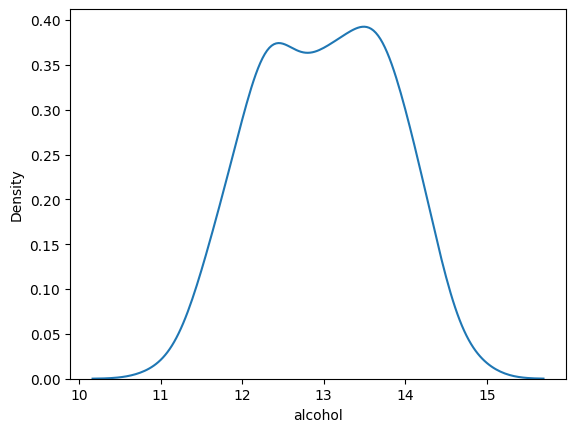

In [35]:
sns.kdeplot(df["alcohol"])

Plot KDE of the `malic_acid` feature to observe its distribution.

<Axes: xlabel='malic_acid', ylabel='Density'>

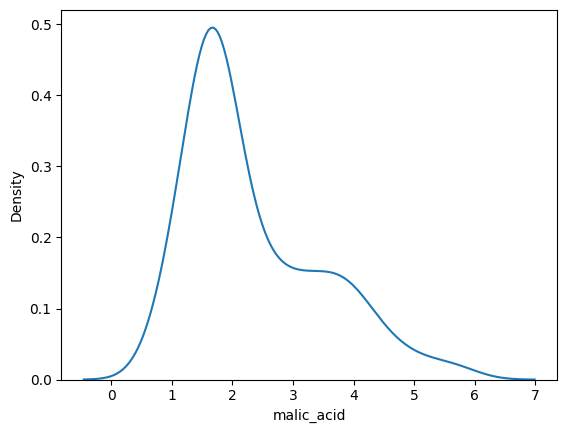

In [36]:
sns.kdeplot(df["malic_acid"])

Separate features into `x` and target `y`.

In [37]:
x = df.drop("class_label", axis = 1)
y = df["class_label"]

Split features and labels: `x` has predictors, `y` has the class label.

In [38]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(x,y, test_size= 0.3, random_state = 42)


Split data into training and test sets with 30% test size.

Check the shape of the training set.

In [39]:
X_train.shape

(124, 2)

Inspect the shape of the training features.

In [40]:
X_test.shape

(54, 2)

Inspect the shape of the test features.

In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


Fit a Min-Max scaler on the training data.

In [42]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Apply the fitted scaler to both train and test sets.

In [43]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

Convert the scaled arrays back into DataFrames with the original column names.